# Import Libraries

In [9]:
from sklearn.ensemble import IsolationForest
import pandas as pd
import seaborn as sns
from urllib.request import urlretrieve
import os

In [10]:
sns.set_style('whitegrid')

# Download Dataset

In [11]:
# download data
file_name = 'dataset.csv'
if os.path.exists(file_name):
    print(f'File: {file_name} exists, skip downloading')
else:
    url = 'https://raw.githubusercontent.com/andymcdgeo/Petrophysics-Python-Series/refs/heads/master/Data/Xeek_Well_15-9-15.csv'
    path, response = urlretrieve(url, file_name)
    print(f'File: {file_name}, downloaded to: {path}')

In [ ]:
df = pd.read_csv(file_name)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17717 entries, 0 to 17716
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   WELL       17717 non-null  str    
 1   DEPTH_MD   17717 non-null  float64
 2   GROUP      17717 non-null  str    
 3   FORMATION  15093 non-null  str    
 4   CALI       17635 non-null  float64
 5   RDEP       17717 non-null  float64
 6   RHOB       17521 non-null  float64
 7   GR         17717 non-null  float64
 8   NPHI       13346 non-null  float64
 9   PEF        17662 non-null  float64
 10  DTC        17708 non-null  float64
 11  LITH       17717 non-null  str    
dtypes: float64(8), str(4)
memory usage: 2.2 MB


In [4]:
df = df.dropna()

## Build IsolationForest model ( 2 features )

In [28]:
anomaly_inputs = ['NPHI', 'RHOB']

model = IsolationForest(contamination=0.01, random_state=32)

model.fit(df[anomaly_inputs])

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.01
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",32
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


<Axes: xlabel='NPHI', ylabel='Count'>

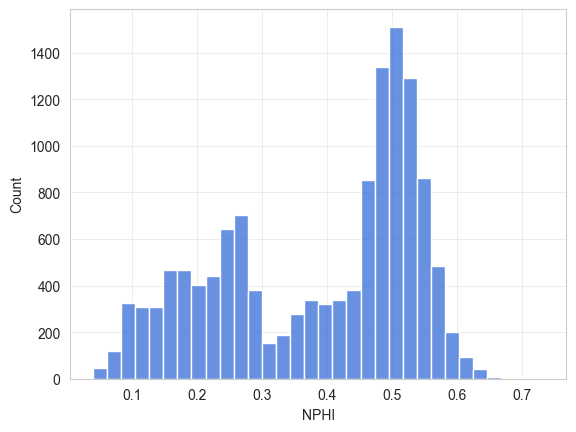

In [29]:
sns.histplot(data=df, x='NPHI')

<Axes: xlabel='RHOB', ylabel='Count'>

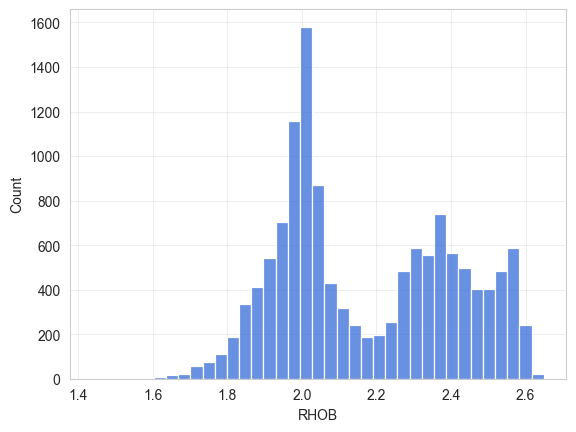

In [30]:
sns.histplot(data=df, x='RHOB')

In [31]:
df['anomaly_scores'] = model.decision_function(df[anomaly_inputs])
df['anomaly'] = model.predict(df[anomaly_inputs])

In [32]:
df.head(10)

,WELL,DEPTH_MD,GROUP,FORMATION,CALI,RDEP,RHOB,GR,NPHI,PEF,DTC,LITH,anomaly_scores,anomaly
4371,15/9-15,1149.648,HORDALAND GP.,Utsira Fm.,17.482092,1.714187,2.063168,68.388885,0.541850,2.583011,134.226379,Shale,0.177044,1
4372,15/9-15,1149.800,HORDALAND GP.,Utsira Fm.,17.395611,1.716345,2.051136,71.170013,0.545401,2.506672,134.824799,Shale,0.194326,1
4373,15/9-15,1149.952,HORDALAND GP.,Utsira Fm.,17.364607,1.719259,2.041540,74.497498,0.548953,2.427594,135.037079,Shale,0.197781,1
4374,15/9-15,1150.104,HORDALAND GP.,Utsira Fm.,17.371887,1.723307,2.035698,76.098335,0.549356,2.401553,134.500336,Shale,0.203300,1
4375,15/9-15,1150.256,HORDALAND GP.,Utsira Fm.,17.370705,1.729302,2.029099,74.966675,0.543351,2.358777,132.162399,Shale,0.219112,1
4376,15/9-15,1150.408,HORDALAND GP.,Utsira Fm.,17.376644,1.734800,2.025343,70.875557,0.543856,2.321016,129.908463,Shale,0.217589,1
4377,15/9-15,1150.560,HORDALAND GP.,Utsira Fm.,17.405724,1.735535,2.025087,66.317642,0.552114,2.313037,129.410767,Shale,0.207011,1
4378,15/9-15,1150.712,HORDALAND GP.,Utsira Fm.,17.356459,1.728027,2.021332,63.439629,0.546547,2.264457,129.570862,Shale,0.217134,1
4379,15/9-15,1150.864,HORDALAND GP.,Utsira Fm.,17.280125,1.714520,2.014690,63.895557,0.525812,2.228987,131.083984,Shale,0.239643,1
4380,15/9-15,1151.016,HORDALAND GP.,Utsira Fm.,17.252224,1.700796,2.004890,66.613991,0.498618,2.225478,135.125992,Shale,0.247972,1


In [33]:
len(df[df['anomaly'] == -1])

133

In [34]:
def outlier_plot(data: pd.DataFrame,
                 method: str,
                 X_var,
                 y_var,
                 x_axis_limits: tuple,
                 y_axis_limits: tuple):
    if x_axis_limits is None:
        x_axis_limits = (0,1)
    if y_axis_limits is None:
        y_axis_limits = (0,1)

    method_name = f'Outlier Method: {method}'
    outliers = len(data[data['anomaly'] == -1])
    non_outliers = len(data[data['anomaly'] == 1])

    print(f'Number of anomaly values: {outliers}')
    print(f'Number of non-anomaly values: {non_outliers}')
    print(f'Total values: {len(data)}')

    g = sns.FacetGrid(data, col='anomaly', height=4, hue='anomaly', hue_order=[1, -1])
    g.map(sns.scatterplot, X_var, y_var)
    g.figure.suptitle(t=method_name, y=1.1, fontweight='bold')
    g.set(xlim=x_axis_limits, ylim=y_axis_limits)
    axes = g.axes.flatten()
    axes[0].set_title(f'Outliers: {outliers}')
    axes[1].set_title(f'Non-Outliers: {non_outliers}')
    return g


Number of anomaly values: 133
Number of non-anomaly values: 13157
Total values: 13290


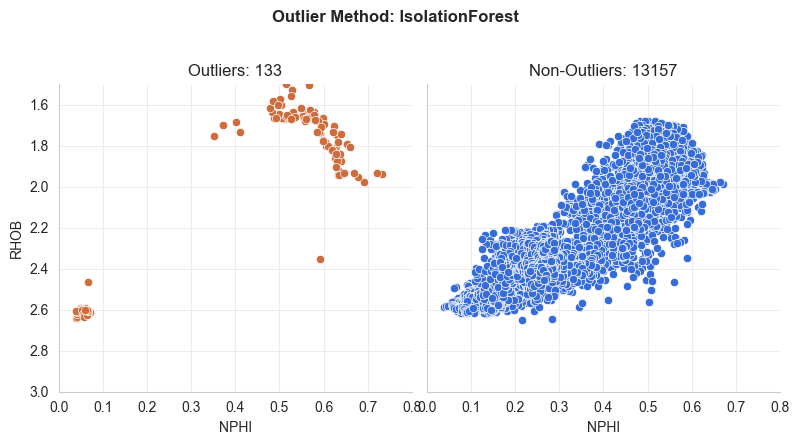

In [35]:
outlier_plot(df, "IsolationForest", "NPHI", "RHOB", (0, 0.8), (3, 1.5))

# MultiFeatures Model

In [23]:
anomaly_inputs = ['NPHI', 'RHOB', 'GR', 'CALI', 'PEF', 'DTC']

mf_model = IsolationForest(contamination=0.1, random_state=42)
mf_model.fit(df[anomaly_inputs])
df['anomaly_scores'] = mf_model.decision_function(df[anomaly_inputs])
df['anomaly'] = mf_model.predict(df[anomaly_inputs])


Number of anomaly values: 1329
Number of non-anomaly values: 11961
Total values: 13290


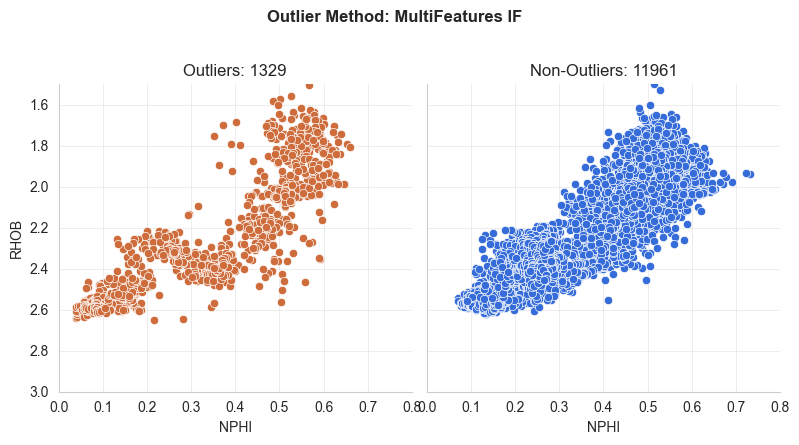

In [24]:
outlier_plot(df, 'MultiFeatures IF', 'NPHI', 'RHOB', (0, 0.8), (3, 1.5))

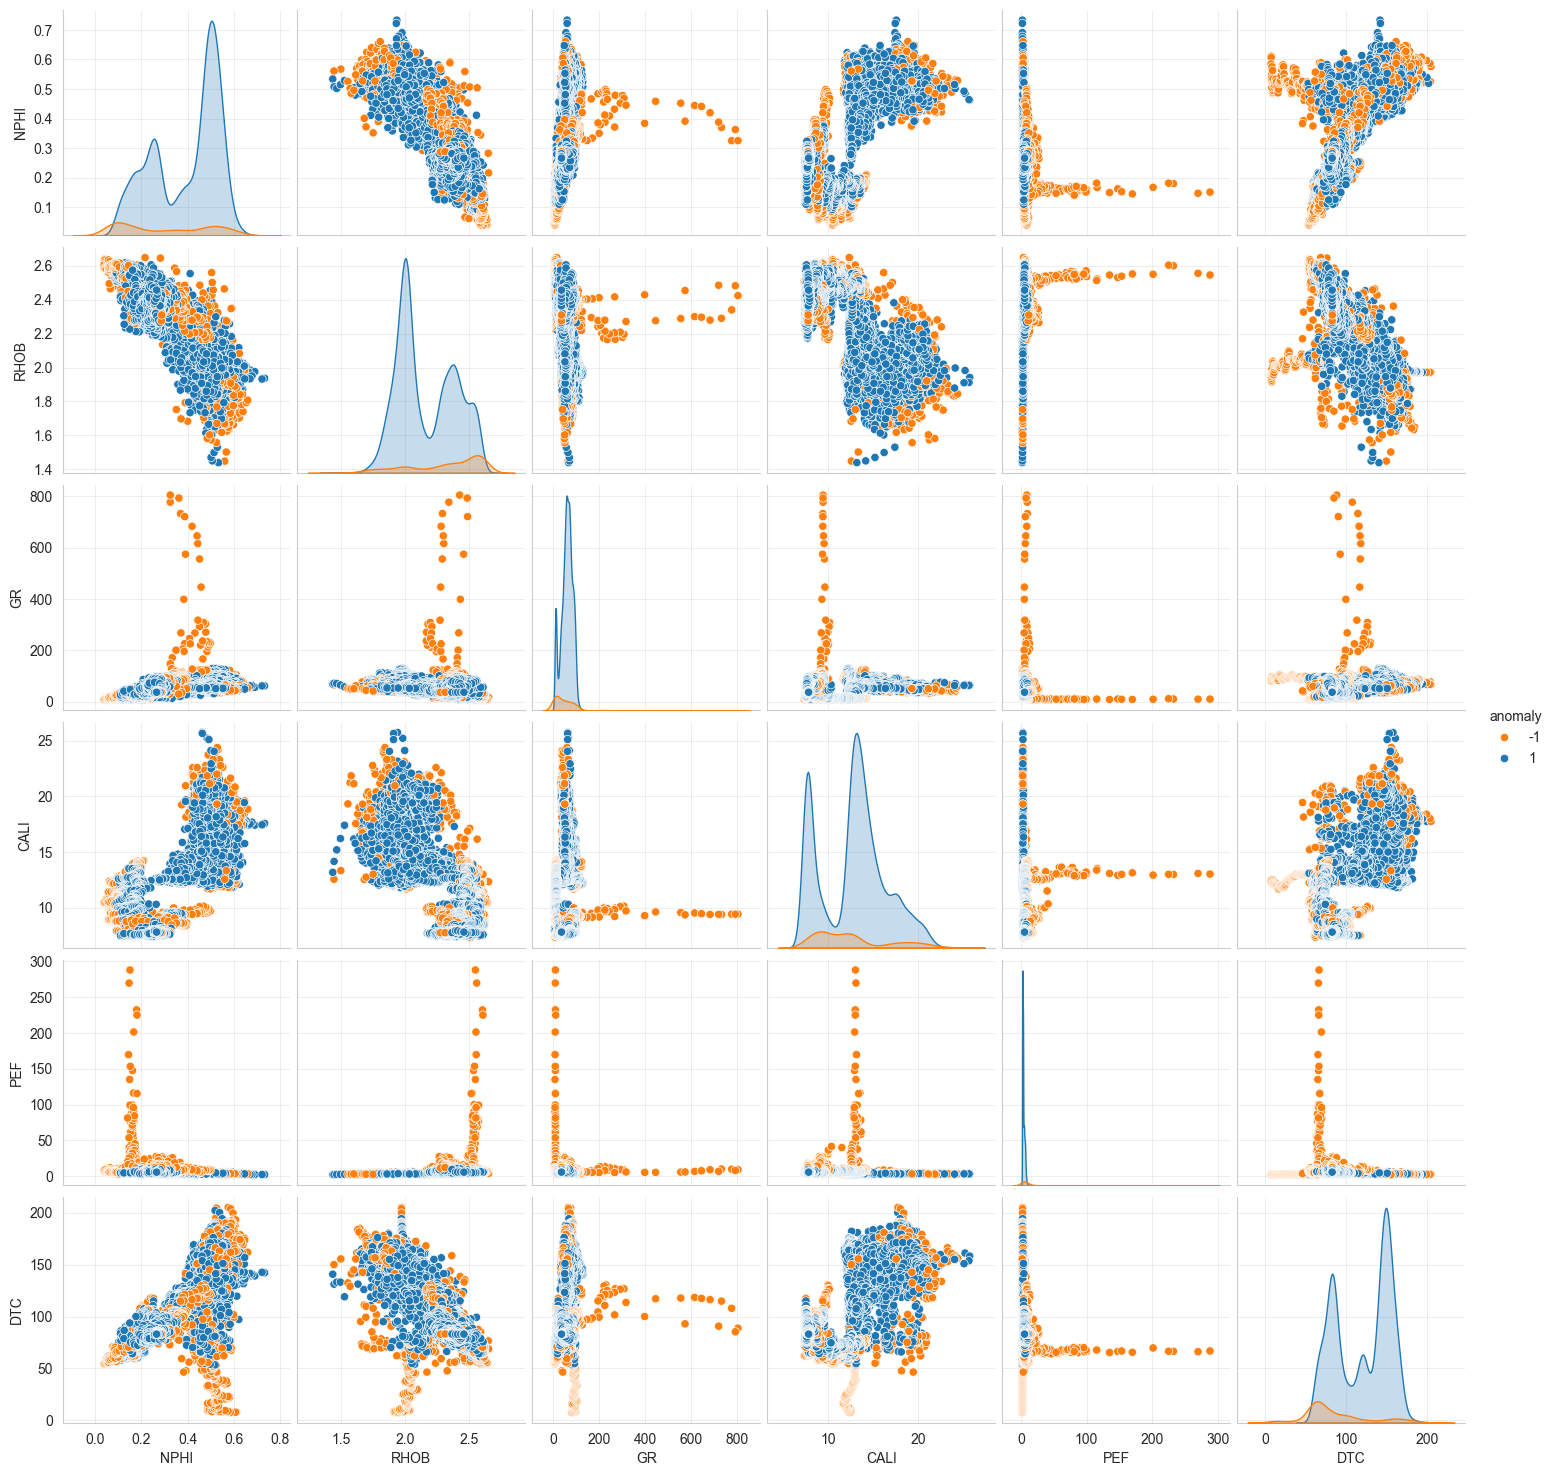

In [25]:
palette = ['#ff7f0e', '#1f77b4']
sns.pairplot(df, vars=anomaly_inputs, hue='anomaly', palette=palette)

# Clean-up

In [13]:
os.remove(file_name)